In [1]:
!pip install xgboost

In [2]:
# ============================================
# Dallas 311 Service Requests - Full ML Project
# Based on original code + added ML models
# ============================================

# =========================
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier


In [3]:
# Load Data
data_311 = pd.read_csv(
    r"C:\Users\Trong Nguyen\Downloads\311_Service_Requests_20260418.csv"
)

print("Original shape:", data_311.shape)
print("\nColumns:")
print(data_311.columns)
print("\nInfo:")
print(data_311.info())
print("\nFirst 5 rows:")
print(data_311.head())


Original shape: (31485, 16)

Columns:
Index(['Service Request Number', 'Address', 'City Council District',
       'Department', 'Service Request Type', 'ERT (Estimated Response Time)',
       'Overall Service Request Due Date', 'Status', 'Created Date',
       'Update Date', 'Closed Date', 'Outcome', 'Priority',
       'Method Received Description', 'Unique Key', 'Lat_Long Location'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31485 entries, 0 to 31484
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Service Request Number            31485 non-null  object
 1   Address                           31485 non-null  object
 2   City Council District             31485 non-null  int64 
 3   Department                        31485 non-null  object
 4   Service Request Type              31485 non-null  object
 5   ERT (Estimated Response Time)     3

In [4]:
# Drop Unnecessary Columns
columns_to_drop = [
    'Service Request Number',
    'Unique Key',
    'Address'
]

data_311 = data_311.drop(
    columns=[col for col in columns_to_drop if col in data_311.columns],
    errors='ignore'
)

print("\nShape after dropping unnecessary columns:", data_311.shape)



Shape after dropping unnecessary columns: (31485, 13)


In [5]:
# Group Rare Departments
if 'Department' in data_311.columns:
    min_count = 1000
    dept_counts = data_311['Department'].value_counts()
    common_depts = dept_counts[dept_counts >= min_count].index

    data_311['Department_grouped'] = data_311['Department'].where(
        data_311['Department'].isin(common_depts),
        'Other'
    )
else:
    data_311['Department_grouped'] = 'Other'

print("\nDepartment grouped counts:")
print(data_311['Department_grouped'].value_counts())



Department grouped counts:
Department_grouped
Code Compliance    31485
Name: count, dtype: int64


In [6]:
# Sampling Data
sample_frac = 0.1

sampled_df = data_311.groupby('Department_grouped', group_keys=False)\
    .sample(frac=sample_frac, random_state=42)\
    .reset_index(drop=True)

print("\nSampled shape:", sampled_df.shape)


Sampled shape: (3148, 14)


In [8]:

# Convert Date Columns
sampled_df['Created Date'] = pd.to_datetime(
    sampled_df['Created Date'],
    format='%Y %b %d %I:%M:%S %p',
    errors='coerce'
)

sampled_df['Closed Date'] = pd.to_datetime(
    sampled_df['Closed Date'],
    format='%Y %b %d %I:%M:%S %p',
    errors='coerce'
)

print("Missing Created Date after parsing:", sampled_df['Created Date'].isna().sum())
print("Missing Closed Date after parsing:", sampled_df['Closed Date'].isna().sum())
print("Total rows after parsing:", len(sampled_df))
print(sampled_df[['Created Date', 'Closed Date']].head())

Missing Created Date after parsing: 0
Missing Closed Date after parsing: 18
Total rows after parsing: 3148
         Created Date         Closed Date
0 2025-04-07 16:49:40 2025-04-25 15:24:30
1 2024-06-21 01:08:13 2024-10-01 16:23:13
2 2023-05-05 10:27:43 2023-09-21 13:40:58
3 2024-10-08 08:21:58 2024-10-15 11:12:10
4 2025-06-18 12:33:30 2025-06-20 11:35:07


In [9]:
# Create Response Time
# response time in hours
sampled_df['days_to_close'] = (
    sampled_df['Closed Date'] - sampled_df['Created Date']
).dt.total_seconds() / 3600

print("\nSummary of response time in hours:")
print(sampled_df['days_to_close'].describe())



Summary of response time in hours:
count     3130.000000
mean       575.212326
std       1432.480967
min          0.000000
25%         51.698056
50%        169.844306
75%        450.020972
max      18907.031111
Name: days_to_close, dtype: float64


In [10]:
# Remove Invalid Rows
sampled_df = sampled_df.dropna(subset=['Created Date', 'Closed Date', 'days_to_close'])
sampled_df = sampled_df[sampled_df['days_to_close'] >= 0]

print("\nShape after removing missing/invalid response times:", sampled_df.shape)


Shape after removing missing/invalid response times: (3130, 15)


In [11]:
# Feature Engineering from Date
sampled_df['month'] = sampled_df['Created Date'].dt.month
sampled_df['day_of_week'] = sampled_df['Created Date'].dt.dayofweek
sampled_df['hour'] = sampled_df['Created Date'].dt.hour



In [12]:
# Create Binary Target
# Fast = request closed within 72 hours (3 days)
sampled_df['target'] = (sampled_df['days_to_close'] <= 72).astype(int)
 print("\nTarget distribution:")
print(sampled_df['target'].value_counts())
print("\nTarget proportion:")
print(sampled_df['target'].value_counts(normalize=True))


Target distribution:
target
0    2192
1     938
Name: count, dtype: int64

Target proportion:
target
0    0.700319
1    0.299681
Name: proportion, dtype: float64


In [13]:
#  Drop Unnecessary Columns
cols_to_drop = [
    'Closed Date',
    'Update Date',
    'Status',
    'Outcome',
    'Lat_Long Location'
]

sampled_df = sampled_df.drop(
    columns=[col for col in cols_to_drop if col in sampled_df.columns],
    errors='ignore'
)

sampled_df = sampled_df.drop(columns=['Created Date'], errors='ignore')
sampled_df = sampled_df.drop(columns=['Department'], errors='ignore')

print("\nShape after dropping leakage columns:", sampled_df.shape)



Shape after dropping leakage columns: (3130, 12)


In [14]:
#  Handle Service Request Type
if 'Service Request Type' in sampled_df.columns:
    top_types = sampled_df['Service Request Type'].value_counts().nlargest(15).index
    sampled_df['Service Request Type'] = sampled_df['Service Request Type'].where(
        sampled_df['Service Request Type'].isin(top_types),
        'Other'
    )

    sampled_df = pd.get_dummies(
        sampled_df,
        columns=['Service Request Type'],
        drop_first=True
    )

In [15]:
# Clean ERT
if 'ERT (Estimated Response Time)' in sampled_df.columns:
    sampled_df['ERT_days'] = sampled_df['ERT (Estimated Response Time)'].astype(str).str.extract(r'(\d+)')[0]
    sampled_df['ERT_days'] = pd.to_numeric(sampled_df['ERT_days'], errors='coerce')
    sampled_df = sampled_df.drop(columns=['ERT (Estimated Response Time)'], errors='ignore')



In [16]:
# Encode Remaining Categorical Columns
label_cols = [
    'Priority',
    'Method Received Description',
    'Department_grouped'
]

for col in label_cols:
    if col in sampled_df.columns:
        le = LabelEncoder()
        sampled_df[col] = le.fit_transform(sampled_df[col].astype(str))


In [17]:
# One-Hot Encode Other Object Columns
object_cols = sampled_df.select_dtypes(include=['object']).columns.tolist()

# do not include target or already removed columns
if len(object_cols) > 0:
    sampled_df = pd.get_dummies(sampled_df, columns=object_cols, drop_first=True)

print("\nShape after encoding:", sampled_df.shape)




Shape after encoding: (3130, 269)


In [18]:
# Handle Missing Values
for col in sampled_df.columns:
    if sampled_df[col].dtype in ['int64', 'float64', 'bool']:
        sampled_df[col] = sampled_df[col].fillna(sampled_df[col].median())

bool_cols = sampled_df.select_dtypes(include=['bool']).columns
sampled_df[bool_cols] = sampled_df[bool_cols].astype(int)

print("\nTotal missing values after cleaning:", sampled_df.isnull().sum().sum())




Total missing values after cleaning: 0


In [19]:

# Define Features and Target
X = sampled_df.drop(columns=['target', 'days_to_close'])
y = sampled_df['target']

print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (3130, 267)
y shape: (3130,)


In [20]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape, y_train.shape)
print("Test size:", X_test.shape, y_test.shape)




Train size: (2504, 267) (2504,)
Test size: (626, 267) (626,)


In [21]:
# Logistic Regression
log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))




===== Logistic Regression =====
Accuracy: 0.6980830670926518
ROC-AUC: 0.5842198581560284

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.97      0.82       438
           1       0.48      0.05      0.10       188

    accuracy                           0.70       626
   macro avg       0.59      0.51      0.46       626
weighted avg       0.64      0.70      0.60       626

Confusion Matrix:
 [[427  11]
 [178  10]]


In [22]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))




===== Random Forest =====
Accuracy: 0.6533546325878594
ROC-AUC: 0.6312906829884388

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74       438
           1       0.43      0.51      0.47       188

    accuracy                           0.65       626
   macro avg       0.60      0.61      0.61       626
weighted avg       0.67      0.65      0.66       626

Confusion Matrix:
 [[313 125]
 [ 92  96]]


In [23]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n===== XGBoost =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))



===== XGBoost =====
Accuracy: 0.6900958466453674
ROC-AUC: 0.6568177402117945

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.86      0.80       438
           1       0.47      0.29      0.36       188

    accuracy                           0.69       626
   macro avg       0.61      0.58      0.58       626
weighted avg       0.66      0.69      0.66       626

Confusion Matrix:
 [[378  60]
 [134  54]]


In [24]:
# Compare Models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print("\n===== Model Comparison =====")
print(results.sort_values(by='ROC_AUC', ascending=False))



===== Model Comparison =====
                 Model  Accuracy   ROC_AUC
2              XGBoost  0.690096  0.656818
1        Random Forest  0.653355  0.631291
0  Logistic Regression  0.698083  0.584220


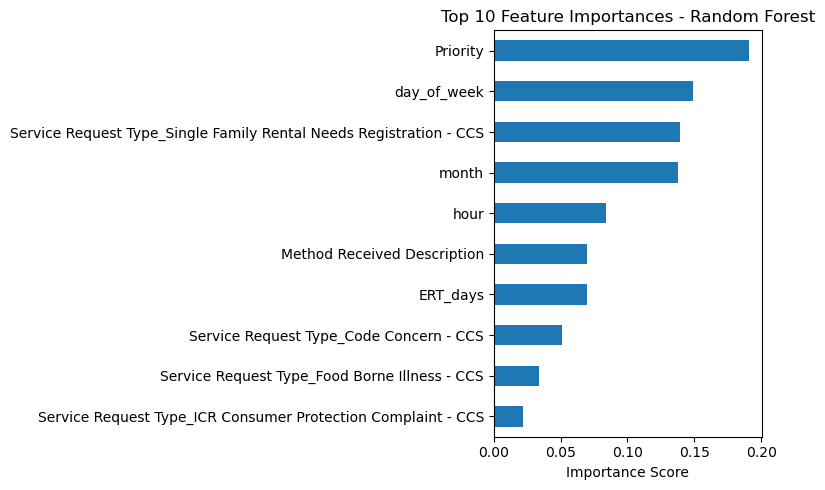

In [25]:
# Feature Importance

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
rf_importance.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


In [27]:
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("\n===== Tuned Random Forest =====")
print("Best Parameters:", rf_search.best_params_)
print("Best CV ROC-AUC:", rf_search.best_score_)

best_rf = rf_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Tuned RF ROC-AUC:", roc_auc_score(y_test, y_prob_best_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))


===== Tuned Random Forest =====
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced_subsample'}
Best CV ROC-AUC: 0.6565747941302735
Tuned RF Accuracy: 0.6565495207667732
Tuned RF ROC-AUC: 0.6484504031866317

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75       438
           1       0.43      0.47      0.45       188

    accuracy                           0.66       626
   macro avg       0.60      0.60      0.60       626
weighted avg       0.67      0.66      0.66       626

Confusion Matrix:
 [[322 116]
 [ 99  89]]
